In [1]:
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
commits = open('commits.txt', 'r',encoding="utf-16").read().splitlines()

In [3]:
commits = commits[:10000]
print("\n".join(commits[:5]))

Fix a stale link to the `math.integer.isqrt()` correctness proof (#154685)
Add the free-threaded Windows build output dirs to `.gitignore` (#154641)
gh-154199: Soft-deprecate `ctypes.util.find_msvcrt` (GH-154553)
gh-150621: avoid quadratic bytes slicing in `asyncio.protocols._feed_data_to_buffered_proto` (#150622)
gh-154493: Add the UCD license to `Doc/license.rst` (#154651)


In [4]:
print(f"longest commit length = {max([len(c) for c in commits])}")
print(f"shortest commit length = {min([len(c) for c in commits])}")

longest commit length = 182
shortest commit length = 13


In [5]:
com_len = torch.Tensor([len(c) for c in commits])
print(int(com_len.mean().item()))

70


In [6]:
vocabs = sorted(list(set(''.join(commits))))

In [7]:
stoi   = {s:i for i,s in enumerate(['^']+vocabs)}
itos   = {i:s for i,s in enumerate(['^']+vocabs)}
block_size = int(com_len.mean().item())
vocab_size = len(vocabs)+1
print('block size = ', block_size)
print('vocab size = ', vocab_size)

block size =  70
vocab size =  95


In [8]:
def build_dataset(commits):
  x, y = [],[]
  for c in commits:
    xx = []
    yy = []
    for ch in '^' + c + '^':
      xx.append(stoi[ch])
      yy.append(stoi[ch])
  
    x.append(torch.tensor(xx[:-1]))
    y.append(torch.tensor(yy[1:]))
  
  return x, y

In [9]:
xtr, ytr = build_dataset(commits[:int(0.9*len(commits))])
xval, yval = build_dataset(commits[int(0.9*len(commits)):])

In [10]:
torch.Generator().manual_seed(2439);

In [11]:
class SelectOutput(nn.Module):
  def __call__(self, x):
    self.out = x[0]
    self.h   = x[1]
    return self.out

  def forward(self, x):
    self.out = x[0]
    self.h   = x[1]
    return self.out

In [13]:
n_embd   = 15
n_hidden = 150

model = nn.Sequential(
                 nn.Embedding(vocab_size, n_embd),
  nn.RNN(input_size=n_embd, hidden_size=n_hidden),
                                   SelectOutput(),
                  nn.Linear(n_hidden, vocab_size),
)
print(f"number of parameters: {sum([p.nelement() for layer in model for p in layer.parameters()])}")

number of parameters: 40820


In [32]:
max_steps = 100000
lossi     = []
psatui    = []
optimizer = torch.optim.AdamW(
  model.parameters(),
  lr=1e-3*2
)
for i in range(1,max_steps+1):
  # -----minibatch-----
  xint = torch.randint(0, len(xtr), (1,))
  x,y = xtr[xint], ytr[xint]
  # -----zero-grad-----
  optimizer.zero_grad()
  
  # -----forward-pass-----
  logits = model(x)
  loss   = F.cross_entropy(logits, y)

  # -----backward-pass-----
  loss.backward()

  # -----update-----
  optimizer.step()

  satu = [i>0.97 for i in model[2].out.abs().view(-1).tolist()]
  persatu = (satu.count(True) / len(satu)) * 100
  
  lossi.append(loss.item())
  psatui.append(persatu)
  
  if i % int(max_steps/20) == 0:
    print(f"Epoch:{i}  |  loss = {loss.item():.4f}")

Epoch:5000  |  loss = 1.7012
Epoch:10000  |  loss = 1.5774
Epoch:15000  |  loss = 1.3876
Epoch:20000  |  loss = 2.0721
Epoch:25000  |  loss = 1.5241
Epoch:30000  |  loss = 1.2060
Epoch:35000  |  loss = 1.9310
Epoch:40000  |  loss = 1.1180
Epoch:45000  |  loss = 1.4545
Epoch:50000  |  loss = 1.5404
Epoch:55000  |  loss = 2.0383
Epoch:60000  |  loss = 1.5963
Epoch:65000  |  loss = 1.1206
Epoch:70000  |  loss = 1.1502
Epoch:75000  |  loss = 1.7250
Epoch:80000  |  loss = 1.5961
Epoch:85000  |  loss = 1.5866
Epoch:90000  |  loss = 1.7388
Epoch:95000  |  loss = 1.6293
Epoch:100000 |  loss = 2.1489


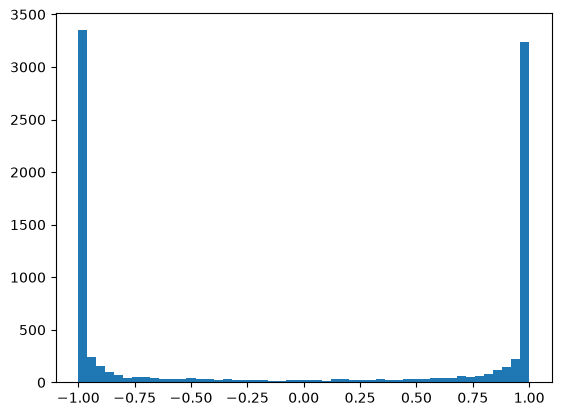

In [33]:
plt.hist(model[2].out.view(-1).tolist(),50);

In [34]:
satu = [i>0.97 for i in model[2].out.abs().view(-1).tolist()]
persatu = (satu.count(True) / len(satu)) * 100
print(f"the saturation of Tanh layer in the RNN layer = {persatu:.4f}%")

the saturation of Tanh layer in the RNN layer = 71.0444%


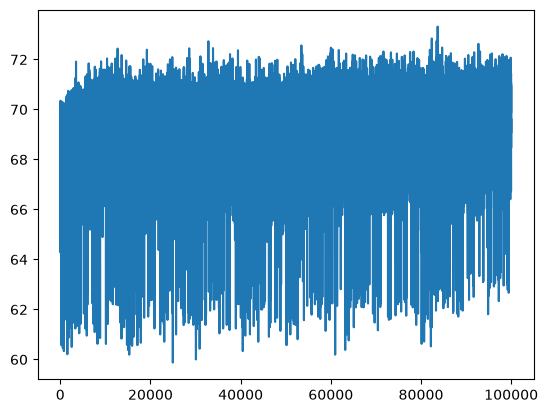

In [35]:
plt.plot(psatui)

In [36]:
def test_val(v=''):
  dataset = {
    'train': (xtr, ytr),
    'val': (xval, yval),
  }

  x,y    = dataset[v]
  xlossi = []
  if v=='train':
    for i in range(len(xtr)):
      xloss = F.cross_entropy(model(x[i]), y[i])
      xlossi.append(xloss.item())

  else:
    for i in range(len(xval)):
      xloss = F.cross_entropy(model(x[i]), y[i])
      xlossi.append(xloss.item())

  loss = torch.tensor(xlossi).mean()

  print(f"{v} loss = {loss.item():.6f}")

In [37]:
test_val('train')
test_val('val')

train loss = 1.492690
val loss = 1.594140


In [38]:
def sample(num_samples):
  
  for _ in range(num_samples):
    ix = stoi['^']
    h = None
    out = []

    while True:
      x = torch.tensor([ix])
      emb = model[0](x)
      rnn_out, h = model[1](emb, h)
      x = rnn_out

      for layer in model[3:]:
        x = layer(x)

      probs = F.softmax(x[-1], dim=0)
      ix = torch.multinomial(
        probs,
        num_samples=1
      ).item()

      if ix == 0:
        break
      out.append(itos[ix])

    print(''.join(out))
    print('')

In [39]:
# to search whether the model is getting some words type from the data or it's just making them up
def search(x: str):
  count= 0
  cont = []
  for c in commits:
    if x.lower() in c.lower():
      cont.append(c)
      count+=1
  print(f'{count} matches found...')
  return cont if cont else None

In [71]:
sample(5)

Use stackmel in test_extension commands (#149829)

gh-123831: Remove return (GH-153865)

gh-134581: make PyUnimeparp.hLED` (#139893)

gh-140166: Remove tails-an (#132866)

gh-136151: Update REPL use encoding output_refarbug (GH-153238)



In [72]:
search('gh-123831')

0 matches found...


In [76]:
a = torch.arange(1, 11, 1)

In [80]:
for k in commits[:100]:
  print(k)
  print('')

Fix a stale link to the `math.integer.isqrt()` correctness proof (#154685)

Add the free-threaded Windows build output dirs to `.gitignore` (#154641)

gh-154199: Soft-deprecate `ctypes.util.find_msvcrt` (GH-154553)

gh-150621: avoid quadratic bytes slicing in `asyncio.protocols._feed_data_to_buffered_proto` (#150622)

gh-154493: Add the UCD license to `Doc/license.rst` (#154651)

gh-153296: Fix thread-safety data race in io.StringIO iterator (#153368)

gh-154043: Fix a data race when iterating a shared `types.GenericAlias` iterator in FT build (#154108)

gh-120866: Document behavior change of asyncio.Server.wait_closed() since 3.12 (#154676)

gh-153290: Fix data race in BytesIO.__setstate__ installing __dict__ (#153376)

GH-153809: Untrack TaskObj from GC before calling unregister_task (#154563)

gh-118150: warn in doc about results asymmetry for difflib junk (GH-153892)

gh-134745: Remove dead code in `thread_nt.h` left by gh-134747 (#154338)

gh-154189: Fix use-after-free in `functoo